# Air Quality Forecasting: Predictive Modeling on UCI Air Quality Dataset
**Dataset:** UCI Machine Learning Repository - Air Quality Dataset

### Project Overview
This project analyzes hourly air quality measurements and chemical multisensor telemetry recorded over a one-year period (March 2004 – April 2005) to forecast future air pollutant concentrations. The primary target variable is future Carbon Monoxide concentration, CO(GT) at +1$ hour, alongside multi-step forecast horizons extending up to 24 hours ahead.

## Part A: Data Understanding & Preprocessing

The UCI Air Quality dataset contains hourly readings from an array of 5 metal oxide semiconductor sensors alongside reference analyzer measurements for CO, NMHC, C6H6, NOx, and NO2.

Key preprocessing challenges:
1. European CSV format: Semicolon delimited with decimal commas.
2. Missing values: Sensor and analyzer failures are tagged with -200.
3. Datetime parsing: Split across Date (DD/MM/YYYY) and Time (HH.MM.SS).
4. High dropout: NMHC(GT) has over 90% missing data due to analyzer failure early in the collection campaign.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
def load_air_quality_data(filepath=None):
    candidates = ['AirQualityUCI.csv', 'data/AirQualityUCI.csv', '../data/AirQualityUCI.csv', 'AirQualityUCI.xlsx']
    target = filepath if (filepath and os.path.exists(filepath)) else next((c for c in candidates if os.path.exists(c)), None)
    
    if target and target.endswith('.xlsx'):
        df = pd.read_excel(target)
    elif target:
        try:
            df = pd.read_csv(target, sep=';', decimal=',', encoding='utf-8')
            if df.shape[1] < 5:
                df = pd.read_csv(target, sep=',', encoding='utf-8')
        except Exception:
            df = pd.read_csv(target, sep=',', encoding='utf-8')
    else:
        # Direct fallback from UCI repository if running in fresh environment
        import urllib.request, zipfile, io
        url = 'https://archive.ics.uci.edu/static/public/360/air+quality.zip'
        req = urllib.request.urlopen(url)
        z = zipfile.ZipFile(io.BytesIO(req.read()))
        df = pd.read_csv(z.open('AirQualityUCI.csv'), sep=';', decimal=',', encoding='utf-8')
        
    drop_cols = [c for c in df.columns if 'Unnamed' in str(c) or str(c).strip() == '']
    df = df.drop(columns=drop_cols, errors='ignore').dropna(how='all')
    return df

df_raw = load_air_quality_data()
print(f'Raw dataset loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
df_raw.head()

Raw dataset loaded: 9357 rows, 15 columns


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


### Missing Values & Sentinel Decoding
In this dataset, -200 represents missing observations. Below, we decode -200 to NaN and calculate the missing percentage for each variable.

In [3]:
df_clean = df_raw.copy()
numeric_cols = [c for c in df_clean.columns if c not in ['Date', 'Time']]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').replace(-200.0, np.nan)

missing_summary = pd.DataFrame({
    'Data_Type': df_clean[numeric_cols].dtypes,
    'Missing_Count': df_clean[numeric_cols].isna().sum(),
    'Missing_Pct (%)': (df_clean[numeric_cols].isna().sum() / len(df_clean) * 100).round(2)
}).sort_values(by='Missing_Pct (%)', ascending=False)

missing_summary

,Data_Type,Missing_Count,Missing_Pct (%)
NMHC(GT),float64,8443,90.23
CO(GT),float64,1683,17.99
NOx(GT),float64,1639,17.52
NO2(GT),float64,1642,17.55
PT08.S1(CO),float64,366,3.91
C6H6(GT),float64,366,3.91
PT08.S2(NMHC),float64,366,3.91
PT08.S3(NOx),float64,366,3.91
PT08.S4(NO2),float64,366,3.91
PT08.S5(O3),float64,366,3.91


### Preprocessing Strategy
1. **Drop NMHC(GT):** With over 90% missing values, imputing this column would introduce artificial patterns. Therefore, it is excluded from the feature set.
2. **Continuous Hourly Index:** Parse Date and Time into a DatetimeIndex and reindex across the entire date range at hourly intervals (`freq='h'`).
3. **Interpolation:** For the remaining features, sporadic gaps are filled using bounded time-based linear interpolation (limit=6 hours) followed by forward/backward fill.

In [4]:
df_clean['Time_Clean'] = df_clean['Time'].astype(str).str.replace('.', ':', regex=False)
df_clean['Timestamp'] = pd.to_datetime(
    df_clean['Date'].astype(str) + ' ' + df_clean['Time_Clean'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)
if df_clean['Timestamp'].isna().sum() > len(df_clean) * 0.5:
    df_clean['Timestamp'] = pd.to_datetime(df_clean['Date'].astype(str) + ' ' + df_clean['Time_Clean'], errors='coerce')

df_clean = df_clean.dropna(subset=['Timestamp']).sort_values('Timestamp').set_index('Timestamp')
df_clean = df_clean.drop(columns=['Date', 'Time', 'Time_Clean', 'NMHC(GT)'], errors='ignore')

full_grid = pd.date_range(start=df_clean.index.min(), end=df_clean.index.max(), freq='h')
df_hourly = df_clean.reindex(full_grid)
df_imputed = df_hourly.interpolate(method='time', limit=6).ffill().bfill()

print(f'Clean continuous dataset shape: {df_imputed.shape}')
print(f'Remaining missing values: {df_imputed.isna().sum().sum()}')

Clean continuous dataset shape: (9357, 12)
Remaining missing values: 0


## Part B: Exploratory Data Analysis (EDA)

In this section, we analyze the statistical distributions of key pollutants, examine sensor correlations, and inspect diurnal and weekly temporal patterns.

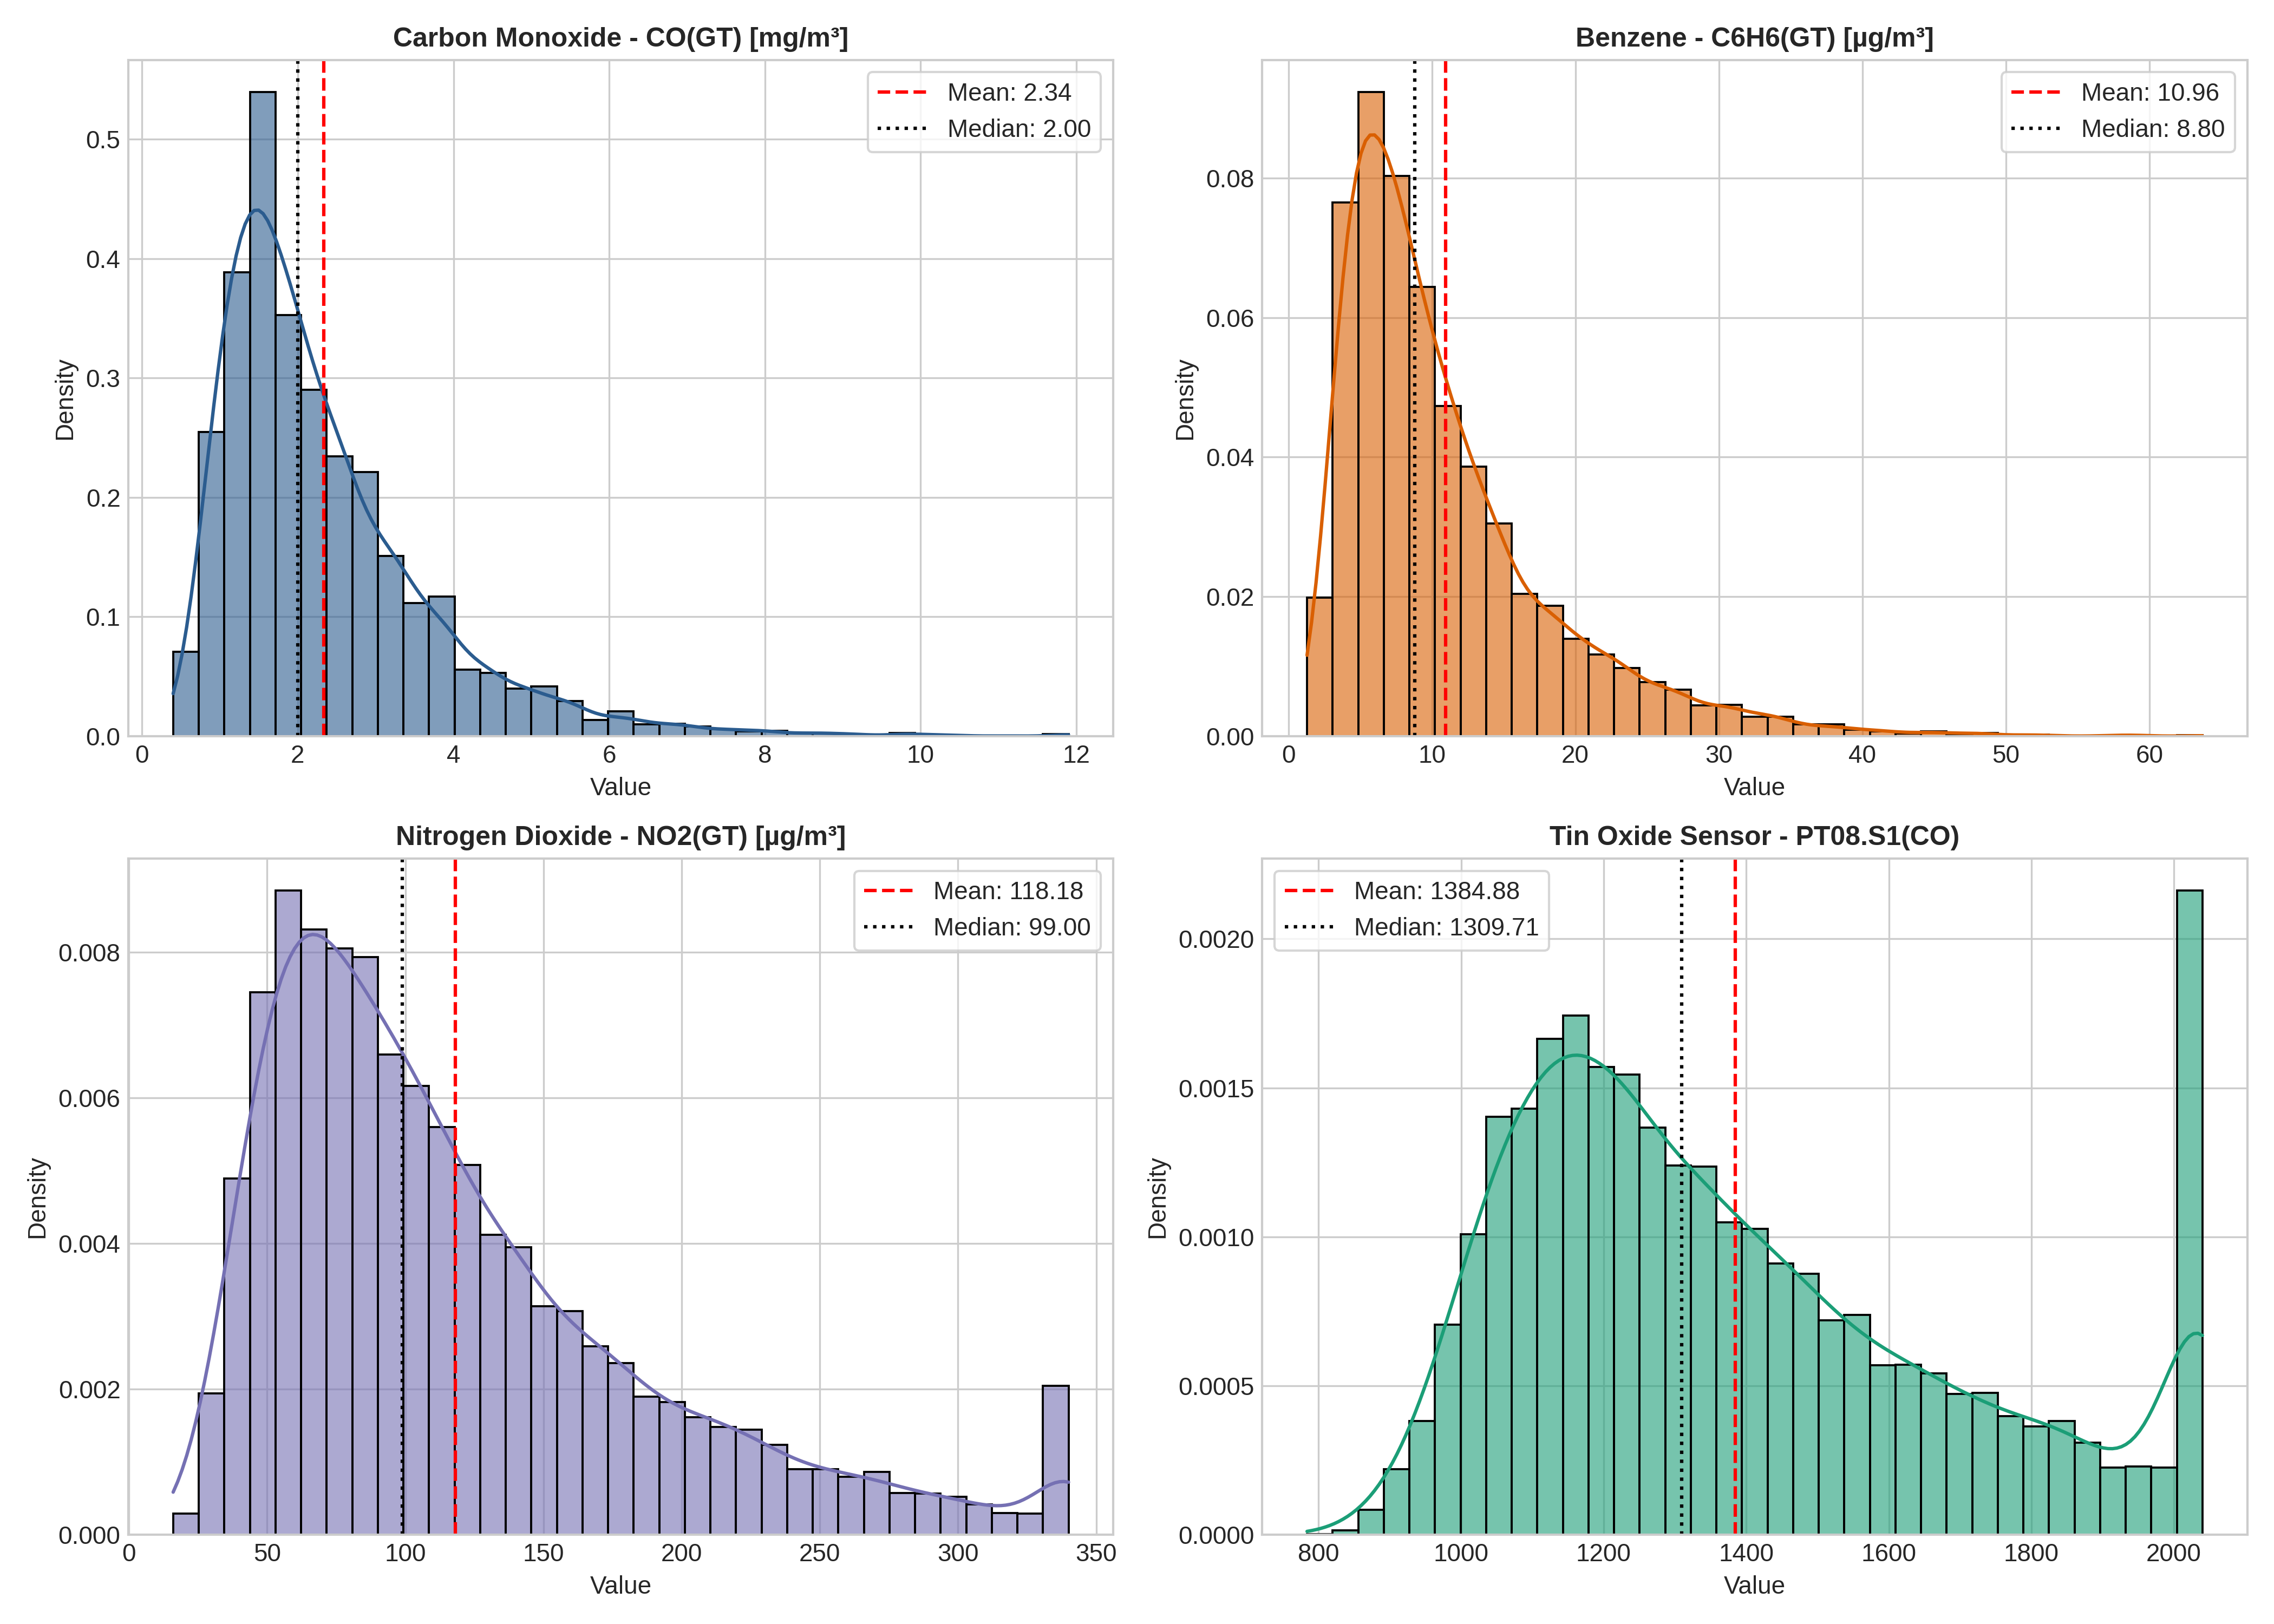

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pollutants = ['CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S1(CO)']
titles = ['Carbon Monoxide - CO(GT) [mg/m³]', 'Benzene - C6H6(GT) [µg/m³]',
          'Nitrogen Dioxide - NO2(GT) [µg/m³]', 'Tin Oxide Sensor - PT08.S1(CO)']
colors = ['#2b5c8f', '#d95f02', '#7570b3', '#1b9e77']

for ax, col, title, color in zip(axes.flatten(), pollutants, titles, colors):
    sns.histplot(df_imputed[col], kde=True, ax=ax, color=color, bins=35, stat='density', alpha=0.6)
    ax.axvline(df_imputed[col].mean(), color='red', linestyle='--', label=f'Mean: {df_imputed[col].mean():.2f}')
    ax.axvline(df_imputed[col].median(), color='black', linestyle=':', label=f'Median: {df_imputed[col].median():.2f}')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Concentration / Sensor Output')
    ax.legend(frameon=True)

plt.tight_layout()
plt.show()

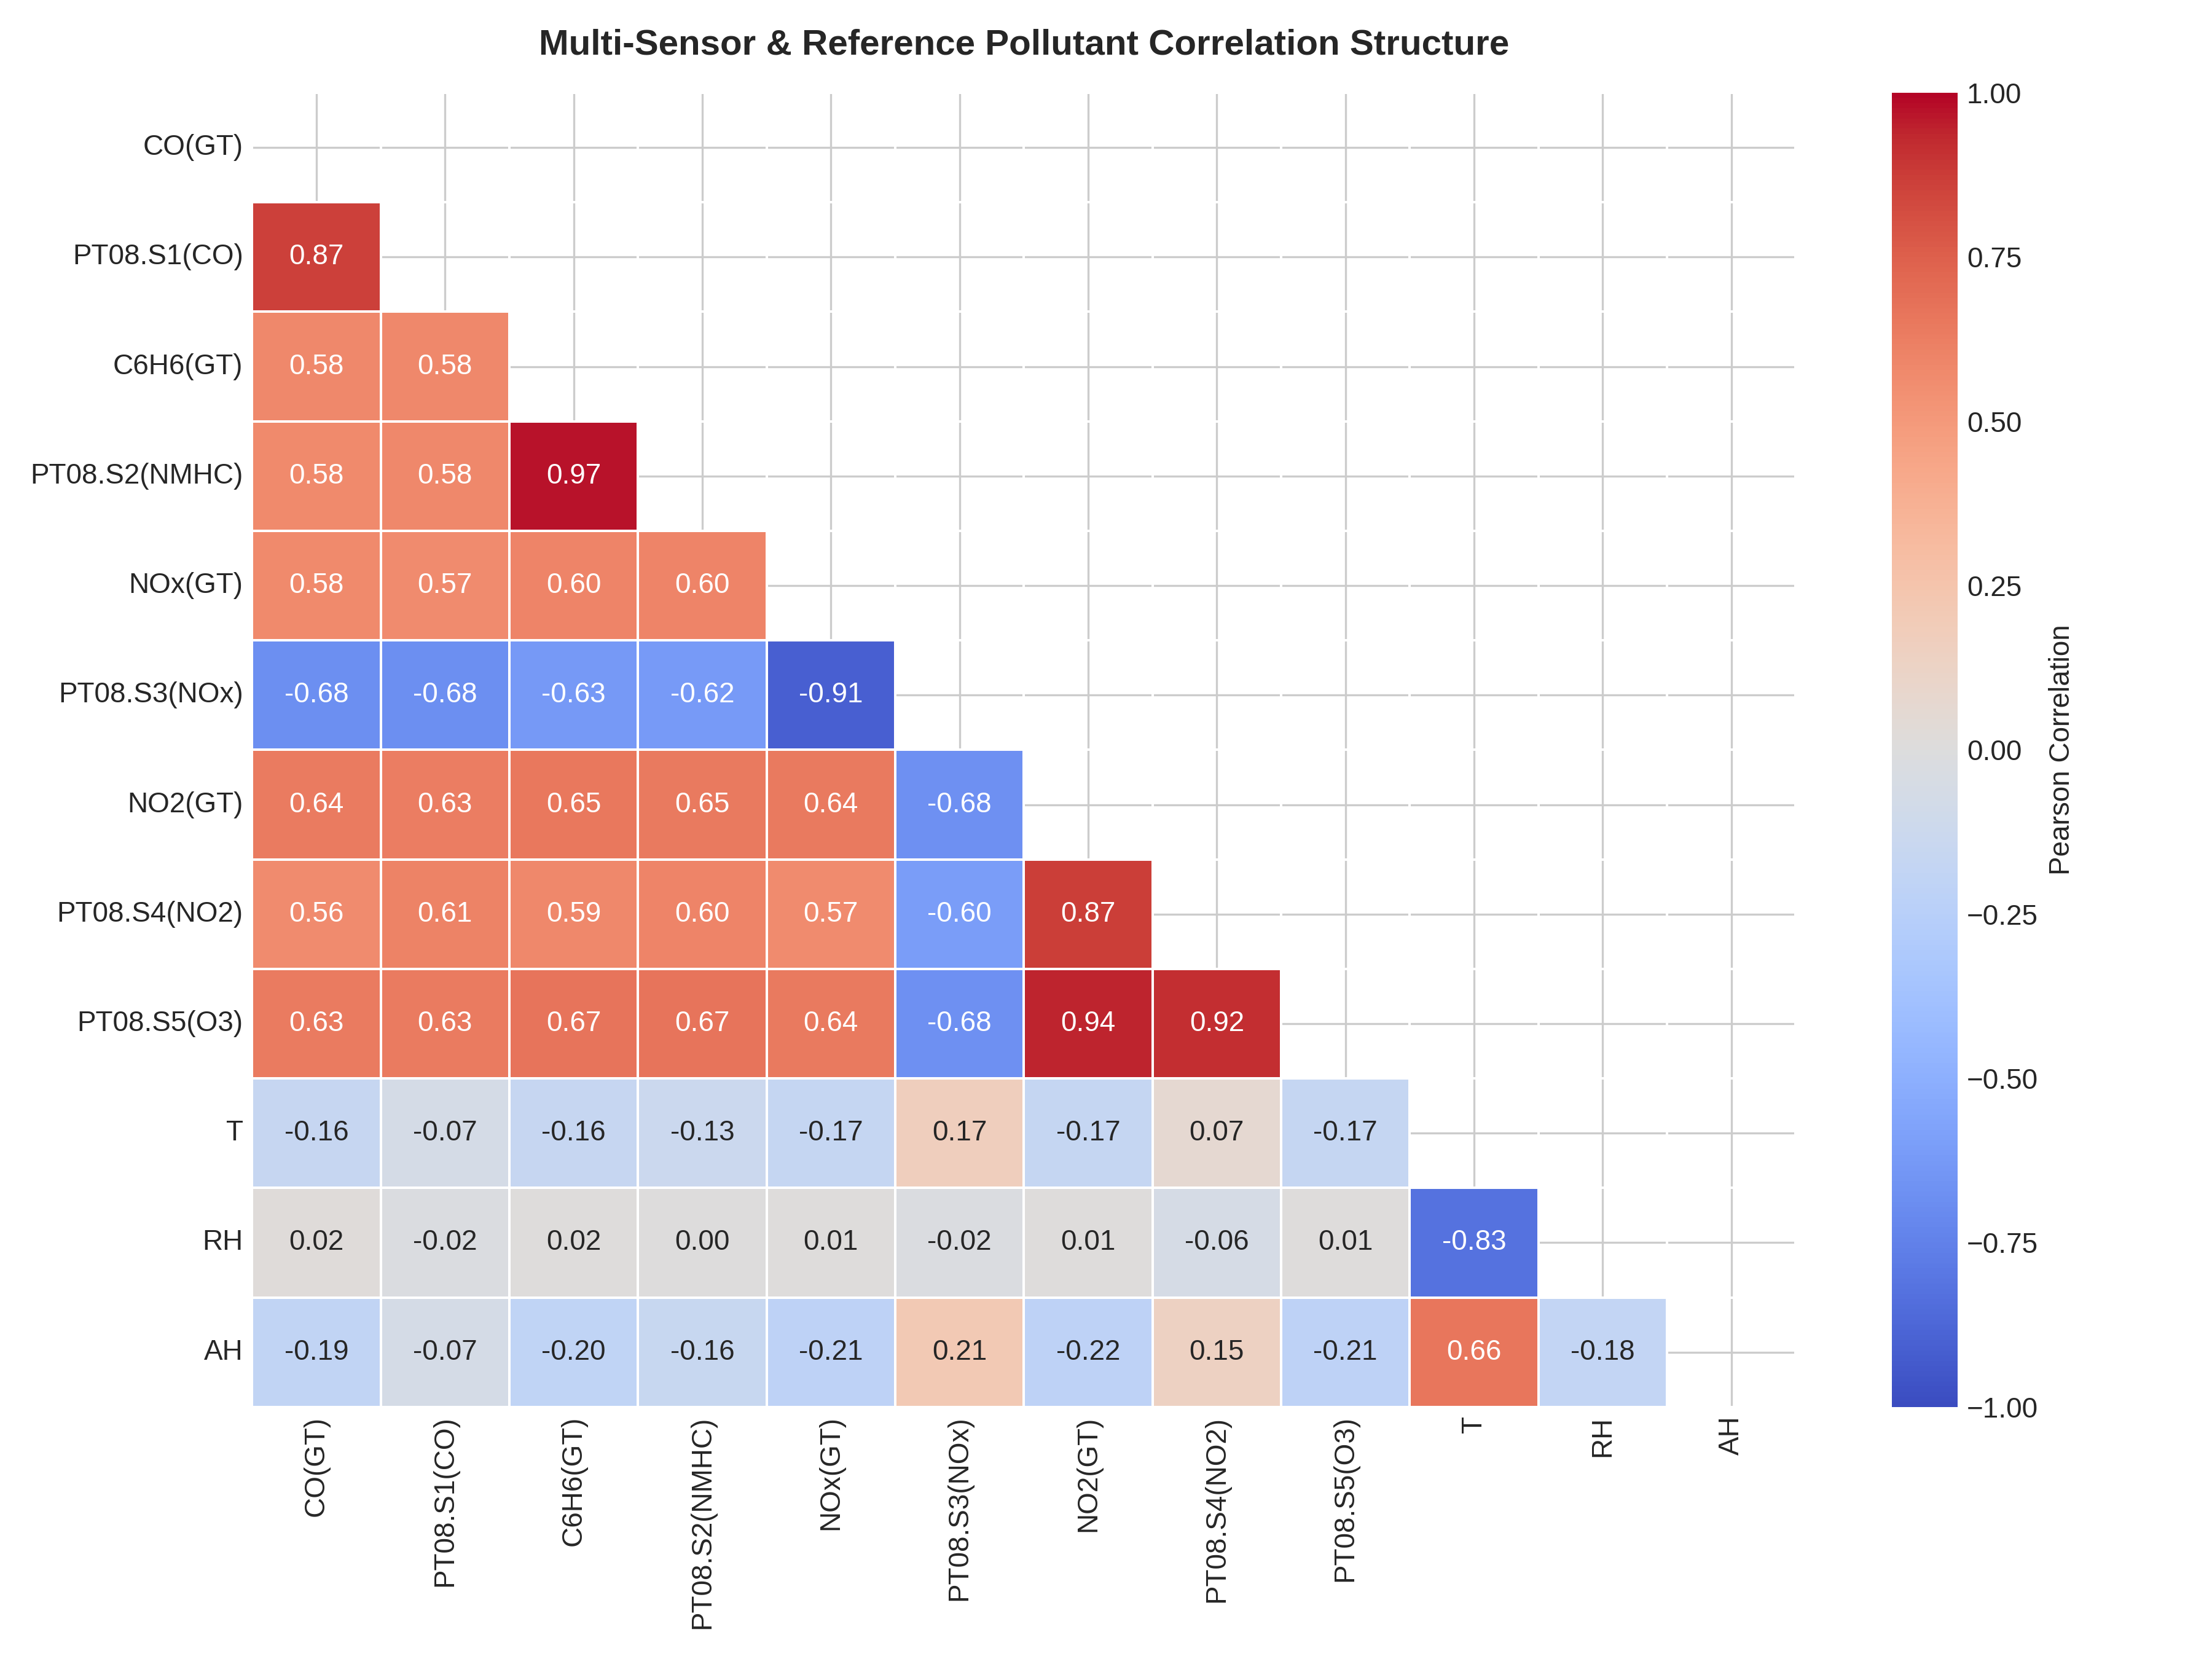

In [6]:
plt.figure(figsize=(12, 9))
corr = df_imputed.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title('Correlation Matrix: Chemical Sensors, Reference Gases & Meteorology', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

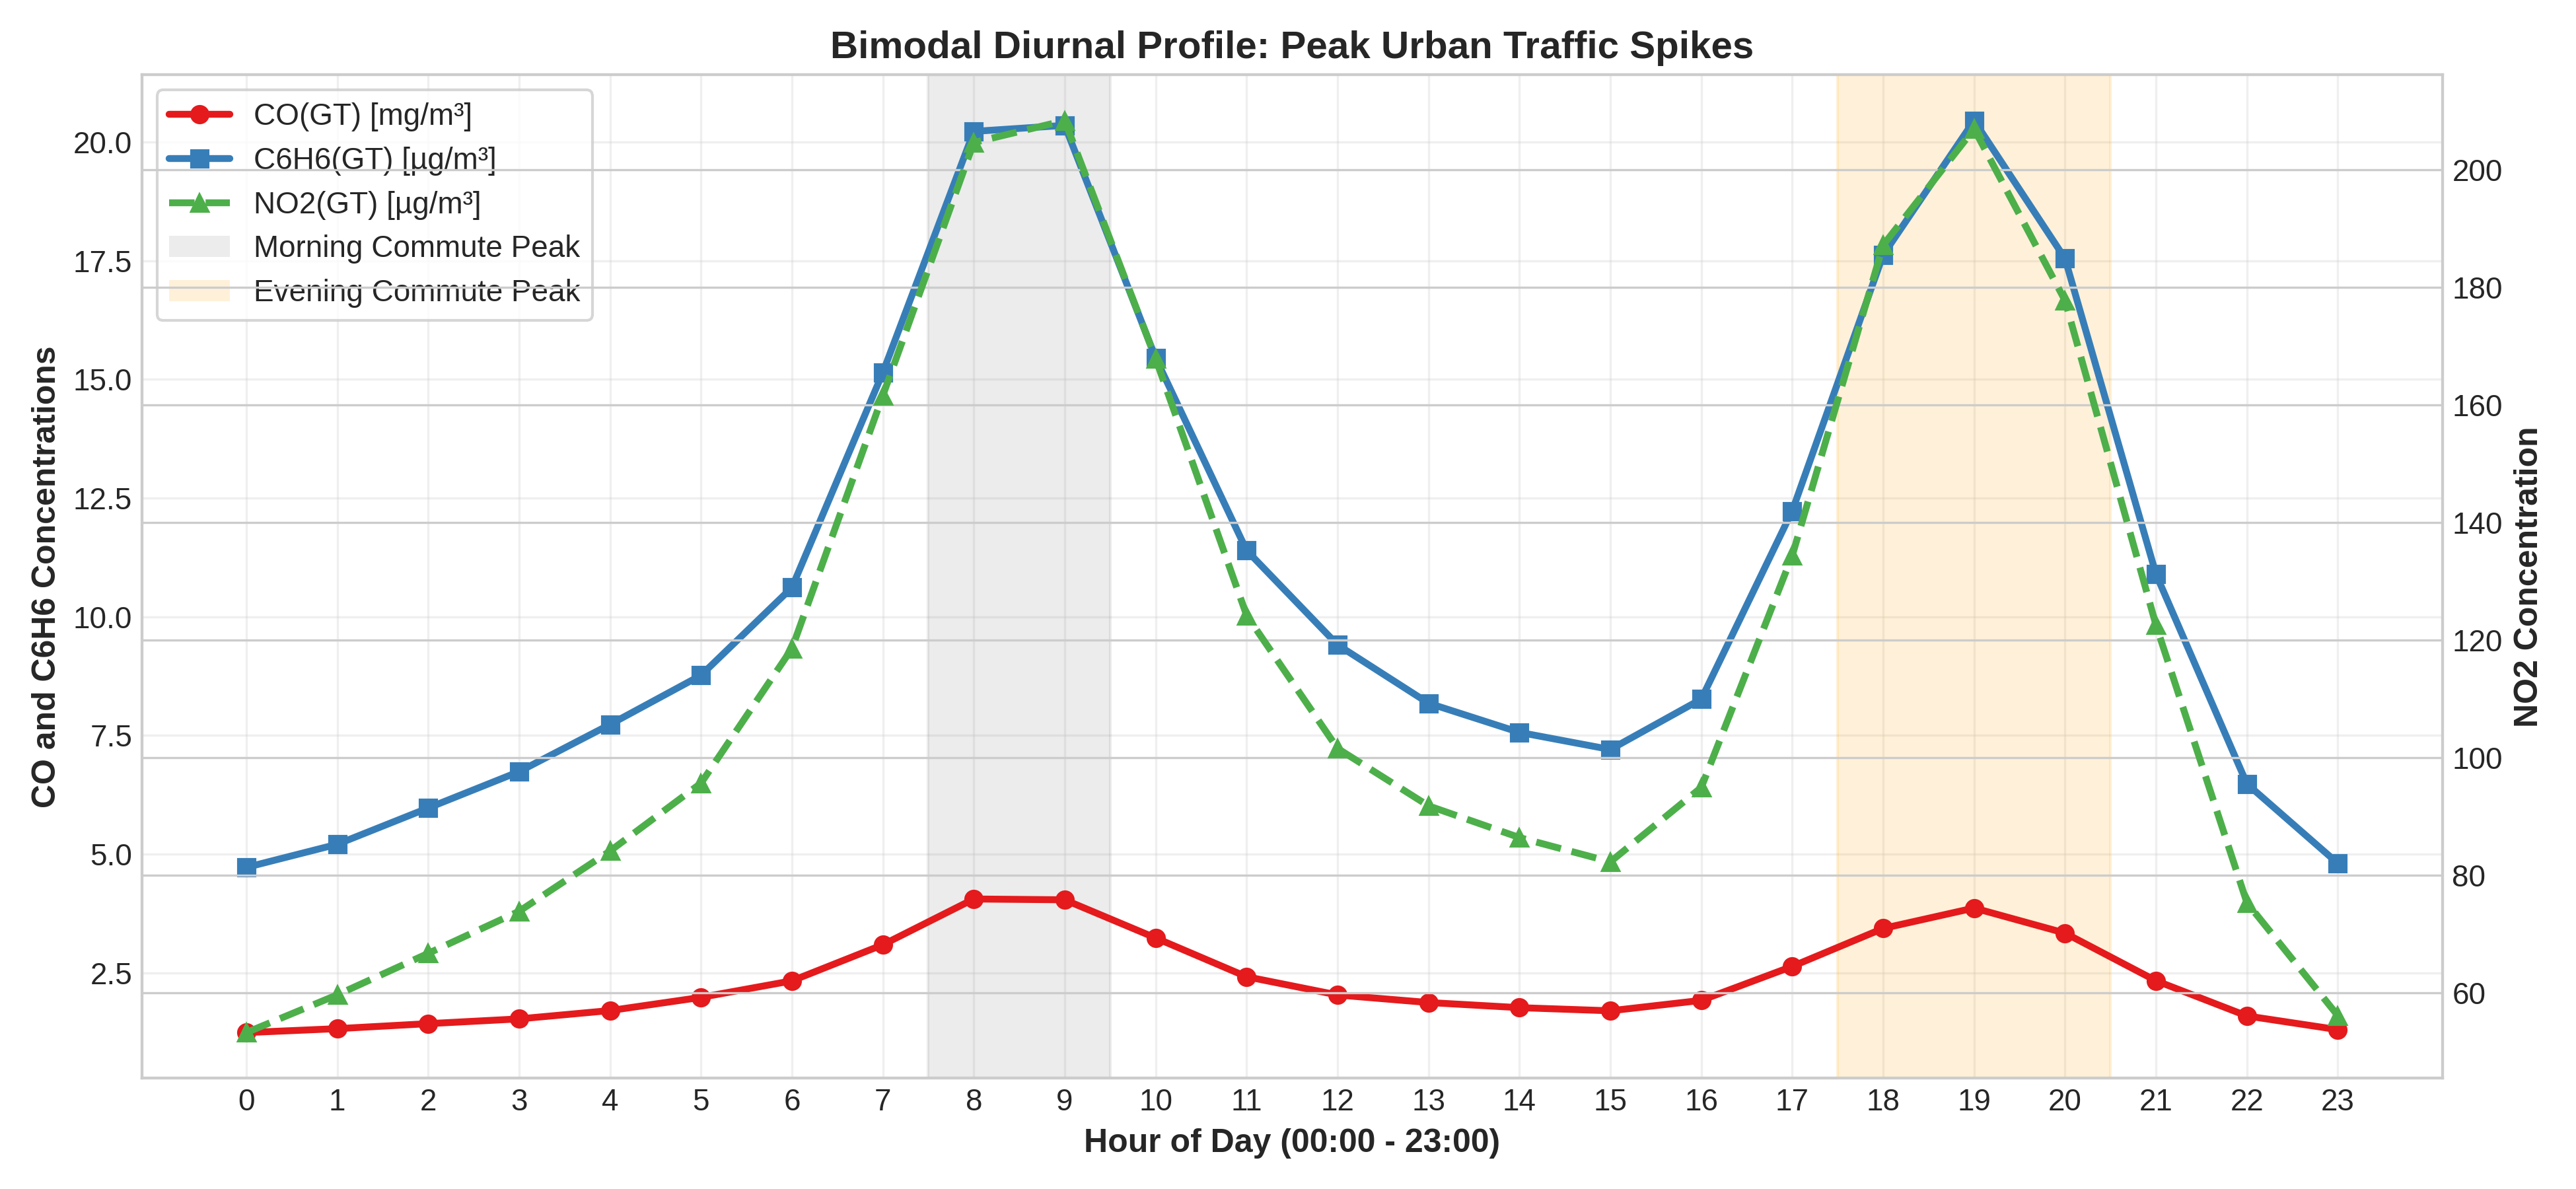

In [7]:
df_imputed['Hour'] = df_imputed.index.hour
df_imputed['DayOfWeek'] = df_imputed.index.day_name()
df_imputed['Is_Weekend'] = df_imputed.index.dayofweek >= 5

hourly_prof = df_imputed.groupby('Hour')[['CO(GT)', 'C6H6(GT)', 'NO2(GT)']].mean()
fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

line1 = ax1.plot(hourly_prof.index, hourly_prof['CO(GT)'], color='#e41a1c', marker='o', lw=2.5, label='CO(GT) [mg/m³]')
line2 = ax1.plot(hourly_prof.index, hourly_prof['C6H6(GT)'], color='#377eb8', marker='s', lw=2.5, label='C6H6(GT) [µg/m³]')
line3 = ax2.plot(hourly_prof.index, hourly_prof['NO2(GT)'], color='#4daf4a', marker='^', lw=2.5, linestyle='--', label='NO2(GT) [µg/m³]')

ax1.set_xlabel('Hour of Day (00:00 - 23:00)', fontsize=12, fontweight='bold')
ax1.set_ylabel('CO and C6H6 Concentrations', fontsize=12, fontweight='bold')
ax2.set_ylabel('NO2 Concentration', fontsize=12, fontweight='bold')
ax1.set_xticks(range(0, 24))
ax1.grid(True, alpha=0.3)
ax1.axvspan(7.5, 9.5, color='gray', alpha=0.15, label='Morning Rush (08:00–09:00)')
ax1.axvspan(17.5, 20.5, color='orange', alpha=0.15, label='Evening Rush (18:00–20:00)')

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines] + ['Morning Rush', 'Evening Rush']
ax1.legend(lines + [plt.Rectangle((0,0),1,1, fc='gray', alpha=0.15), plt.Rectangle((0,0),1,1, fc='orange', alpha=0.15)],
           labels, loc='upper left', frameon=True)
plt.title('Bimodal Diurnal Profile: Urban Traffic Rush-Hour Spikes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

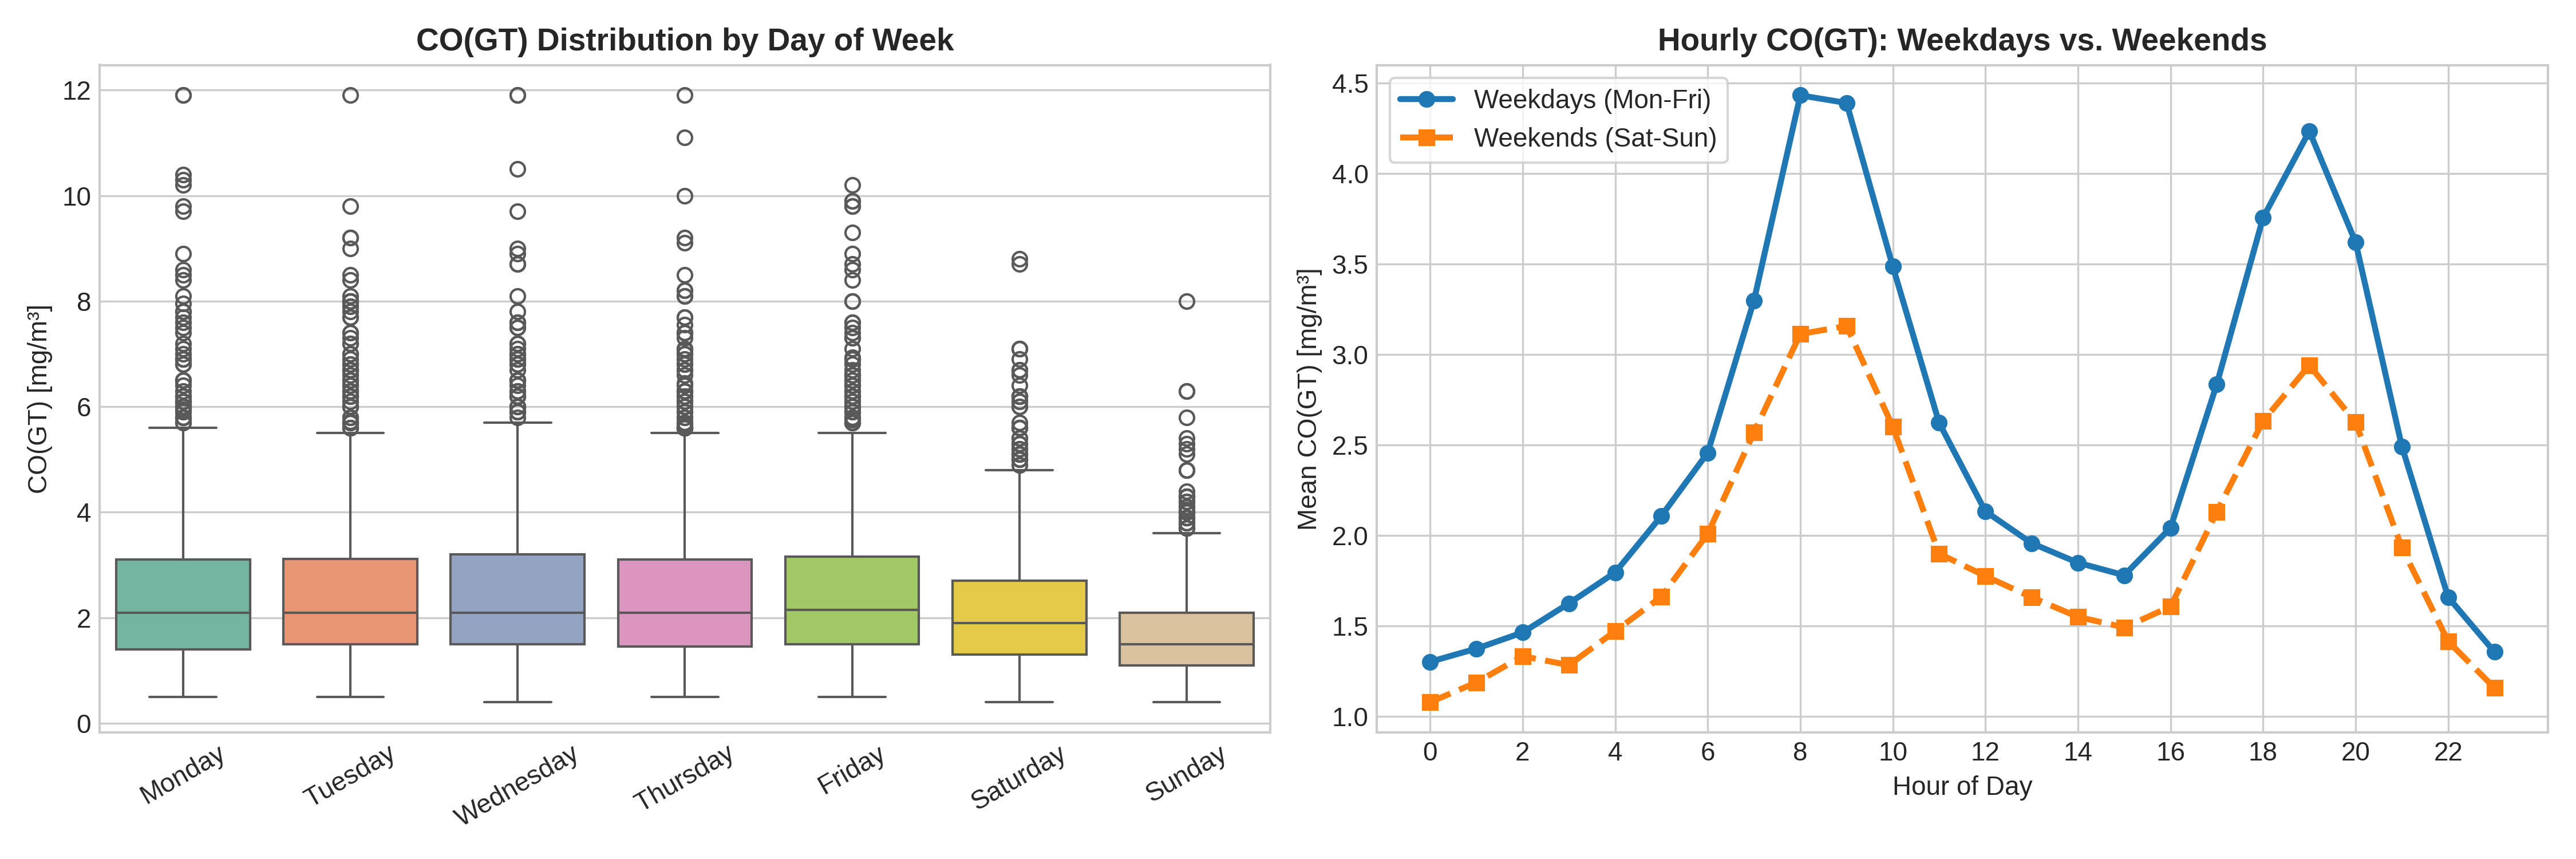

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df_imputed, x='DayOfWeek', y='CO(GT)', order=weekday_order, palette='Set2', ax=axes[0])
axes[0].set_title('CO(GT) by Day of Week', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('CO(GT) [mg/m³]')
axes[0].tick_params(axis='x', rotation=30)

weekday_hourly = df_imputed[~df_imputed['Is_Weekend']].groupby('Hour')['CO(GT)'].mean()
weekend_hourly = df_imputed[df_imputed['Is_Weekend']].groupby('Hour')['CO(GT)'].mean()

axes[1].plot(weekday_hourly.index, weekday_hourly.values, label='Weekdays (Mon-Fri)', color='#1f77b4', lw=2.5, marker='o')
axes[1].plot(weekend_hourly.index, weekend_hourly.values, label='Weekends (Sat-Sun)', color='#ff7f0e', lw=2.5, marker='s', linestyle='--')
axes[1].set_title('Hourly CO(GT): Weekdays vs. Weekends', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean CO(GT) [mg/m³]')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(frameon=True)
plt.tight_layout()
plt.show()

## Part C: Feature Engineering

Features created:
1. Target: Future pollutant concentration CO(GT) at t + horizon (default horizon = 1 hour).
2. Cyclical Temporal Encodings: Sine and cosine transformations of Hour, Day of Week, and Month to capture circular periodic transitions.
3. Autoregressive Lags: Values at t-1, t-2, t-3, and t-24 for the target pollutant and primary sensors.
4. Backward-looking Rolling Statistics: 3h, 6h, and 24h moving averages and standard deviations calculated with a 1-step shift to prevent data leakage.
5. Physical Interaction Terms: Temperature multiplied by Relative Humidity (T * RH) and sensor impedance ratios.

In [9]:
def engineer_features(df_input, target_col='CO(GT)', horizon=1):
    df = df_input.copy()
    df['Target_Future'] = df[target_col].shift(-horizon)
    
    hour = df.index.hour
    dayofweek = df.index.dayofweek
    month = df.index.month
    
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24.0)
    df['dow_sin'] = np.sin(2 * np.pi * dayofweek / 7.0)
    df['dow_cos'] = np.cos(2 * np.pi * dayofweek / 7.0)
    df['month_sin'] = np.sin(2 * np.pi * month / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * month / 12.0)
    df['is_weekend'] = (dayofweek >= 5).astype(int)
    
    lag_targets = [target_col, 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'T', 'RH']
    for col in lag_targets:
        if col in df.columns:
            for lag in [1, 2, 3, 24]:
                df[f'{col}_lag{lag}'] = df[col].shift(lag)
                
    for window in [3, 6, 24]:
        df[f'{target_col}_roll_mean_{window}h'] = df[target_col].shift(1).rolling(window=window).mean()
        df[f'{target_col}_roll_std_{window}h'] = df[target_col].shift(1).rolling(window=window).std()
        if 'PT08.S1(CO)' in df.columns:
            df[f'PT08.S1_roll_mean_{window}h'] = df['PT08.S1(CO)'].shift(1).rolling(window=window).mean()
            
    df['T_RH_interaction'] = df['T'] * df['RH']
    if 'PT08.S1(CO)' in df.columns and 'PT08.S2(NMHC)' in df.columns:
        df['Sensor_Ratio_S1_S2'] = df['PT08.S1(CO)'] / (df['PT08.S2(NMHC)'] + 1e-5)
        
    return df.dropna().copy()

df_featured = engineer_features(df_imputed, target_col='CO(GT)', horizon=1)
print(f'Engineered feature matrix: {df_featured.shape[0]} samples, {df_featured.shape[1]} columns')

Engineered feature matrix: 9332 samples, 55 columns


## Part D: Predictive Modeling & Evaluation

To avoid time-series data leakage, we partition the dataset strictly chronologically (first 80% for training, final 20% for testing). Models evaluated:
1. Naive Persistence Baseline: Predicts CO(GT) at t+1 using current measurement at time t.
2. Ridge Regression: L2-regularized linear baseline.
3. Random Forest Regressor.
4. Gradient Boosting Regressor.

In [10]:
exclude_cols = ['Target_Future', 'Hour', 'DayOfWeek', 'Is_Weekend']
feature_cols = [c for c in df_featured.columns if c not in exclude_cols]

X = df_featured[feature_cols]
y = df_featured['Target_Future']

split_idx = int(len(df_featured) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train period: {X_train.index.min()} to {X_train.index.max()} ({len(X_train)} samples)')
print(f'Test period:  {X_test.index.min()} to {X_test.index.max()} ({len(X_test)} samples)')

# Scale features using parameters fit strictly on the training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train period: 2004-03-11 18:00:00 to 2005-01-16 18:00:00 (7465 samples)
Test period:  2005-01-16 19:00:00 to 2005-04-04 13:00:00 (1867 samples)


In [11]:
models = {
    'Ridge Regression': Ridge(alpha=15.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.08, max_depth=4, random_state=42)
}

predictions = {}
predictions['Persistence Baseline'] = X_test['CO(GT)'].values

for name, model in models.items():
    if name == 'Ridge Regression':
        model.fit(X_train_scaled, y_train)
        predictions[name] = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions[name] = model.predict(X_test)

def evaluate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'MSE': round(mse, 4), 'R2': round(r2, 4)}

results = []
for name, preds in predictions.items():
    res = evaluate_metrics(y_test, preds)
    res['Model'] = name
    results.append(res)

df_results = pd.DataFrame(results).set_index('Model')[['MAE', 'RMSE', 'MSE', 'R2']]
df_results.sort_values(by='RMSE')

Model,MAE,RMSE,MSE,R2
Random Forest,0.7104,1.0622,1.1282,0.5807
Gradient Boosting,0.7131,1.0636,1.1313,0.5795
Ridge Regression,0.7948,1.1739,1.3781,0.4878
Persistence Baseline,1.0251,1.5451,2.3875,0.1127


## Part E: Model Analysis & Error Diagnostics

We now inspect forecast tracking over a 10-day holdout sample, examine residual error distributions, and rank feature importances.

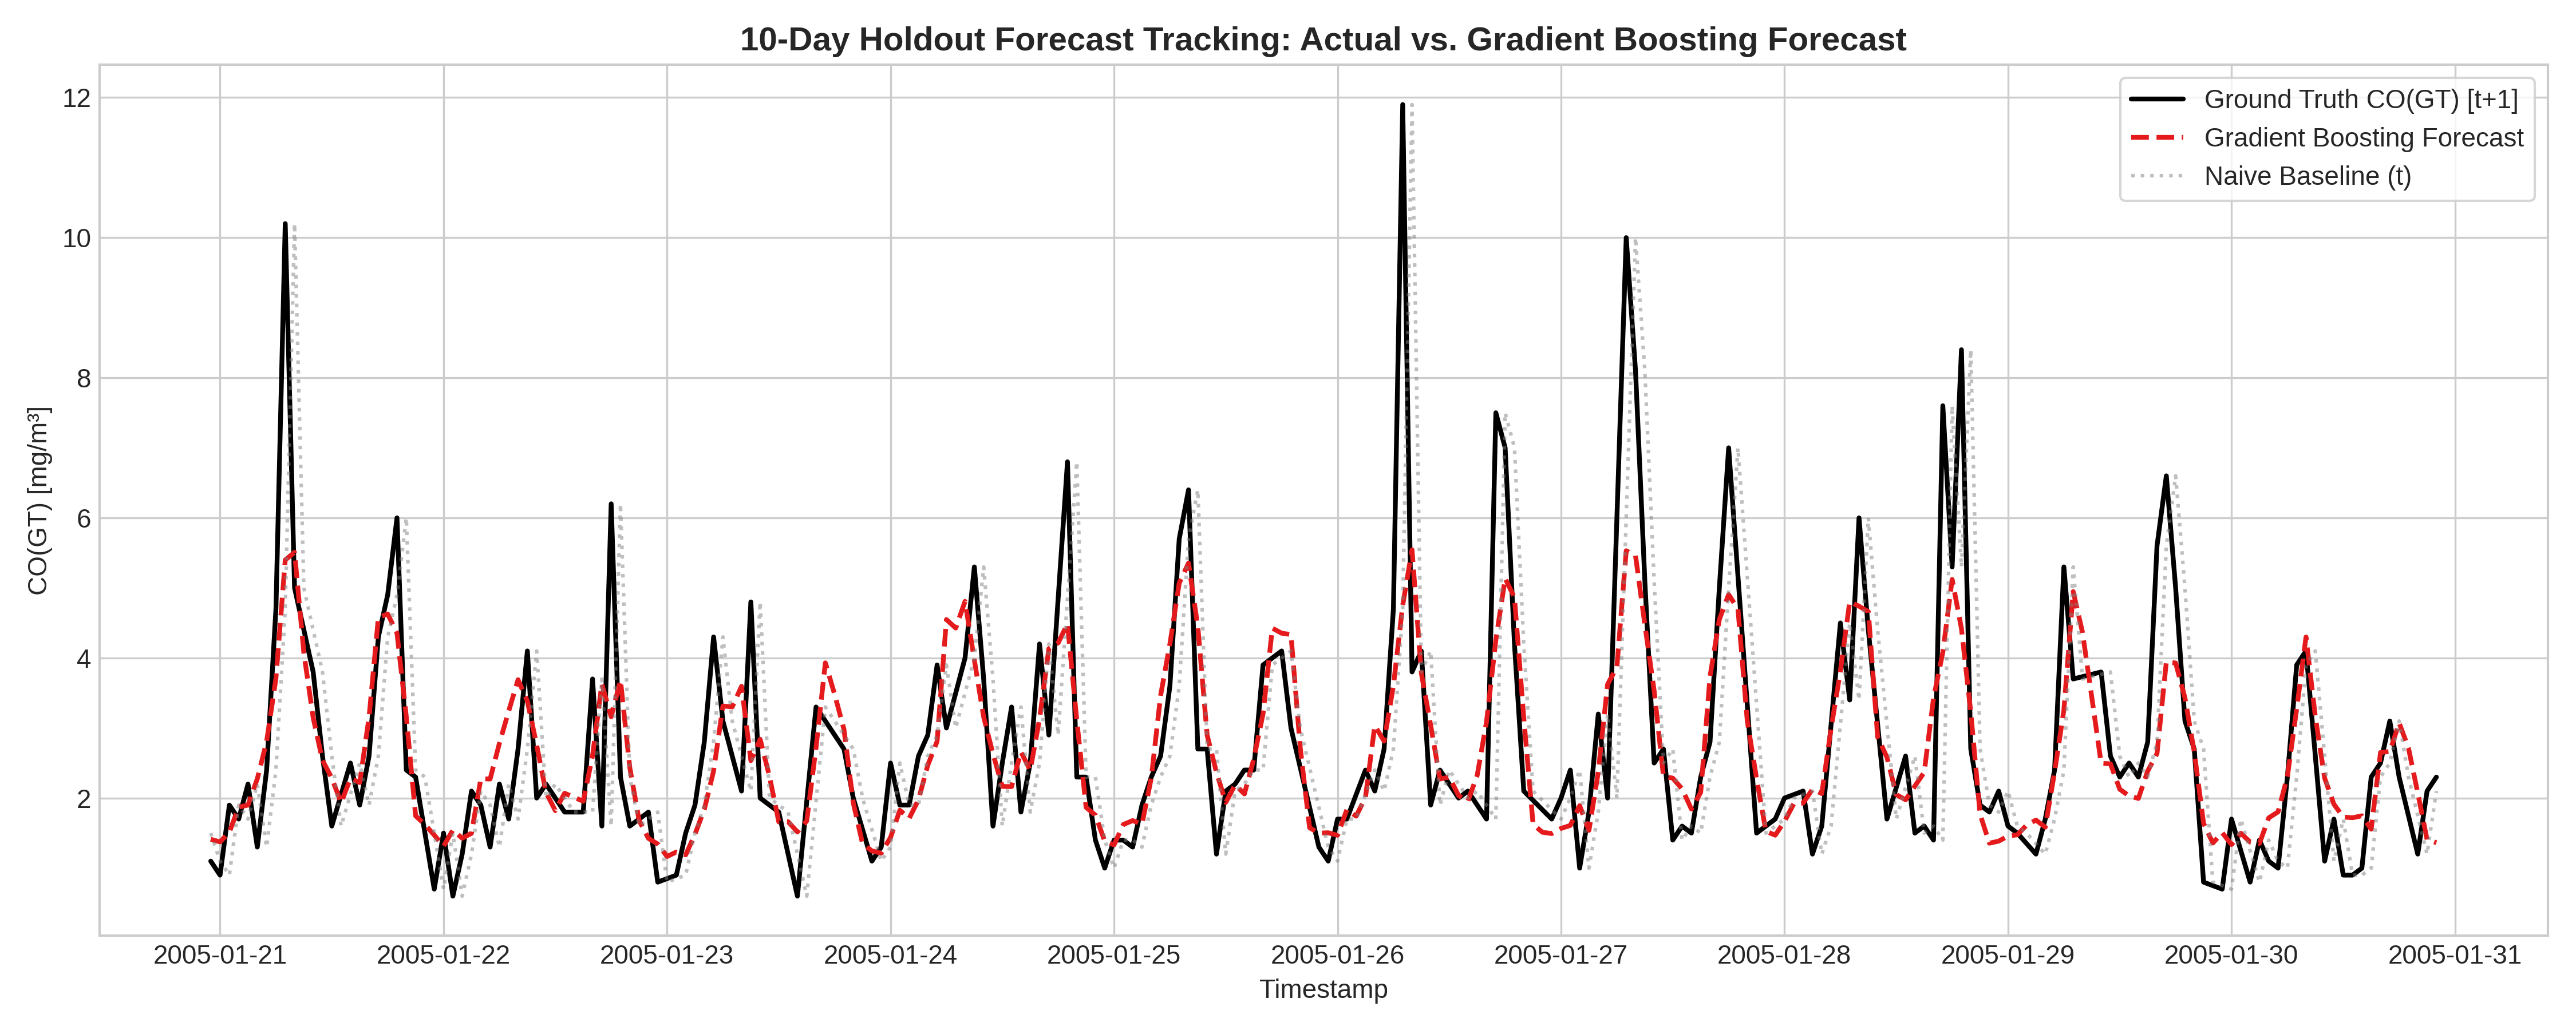

In [12]:
best_model_name = 'Gradient Boosting'
best_preds = predictions[best_model_name]

eval_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': best_preds,
    'Baseline': predictions['Persistence Baseline']
}, index=y_test.index)

sample_window = eval_df.iloc[100:340]

plt.figure(figsize=(15, 6))
plt.plot(sample_window.index, sample_window['Actual'], label='Actual CO(GT) [t+1]', color='black', lw=2)
plt.plot(sample_window.index, sample_window['Predicted'], label=f'{best_model_name} Forecast', color='#e41a1c', lw=2, linestyle='--')
plt.plot(sample_window.index, sample_window['Baseline'], label='Naive Baseline (t)', color='gray', alpha=0.5, linestyle=':')
plt.title('10-Day Holdout Forecast Tracking: Actual vs. Gradient Boosting', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp')
plt.ylabel('CO(GT) [mg/m³]')
plt.legend(frameon=True, loc='upper right')
plt.tight_layout()
plt.show()

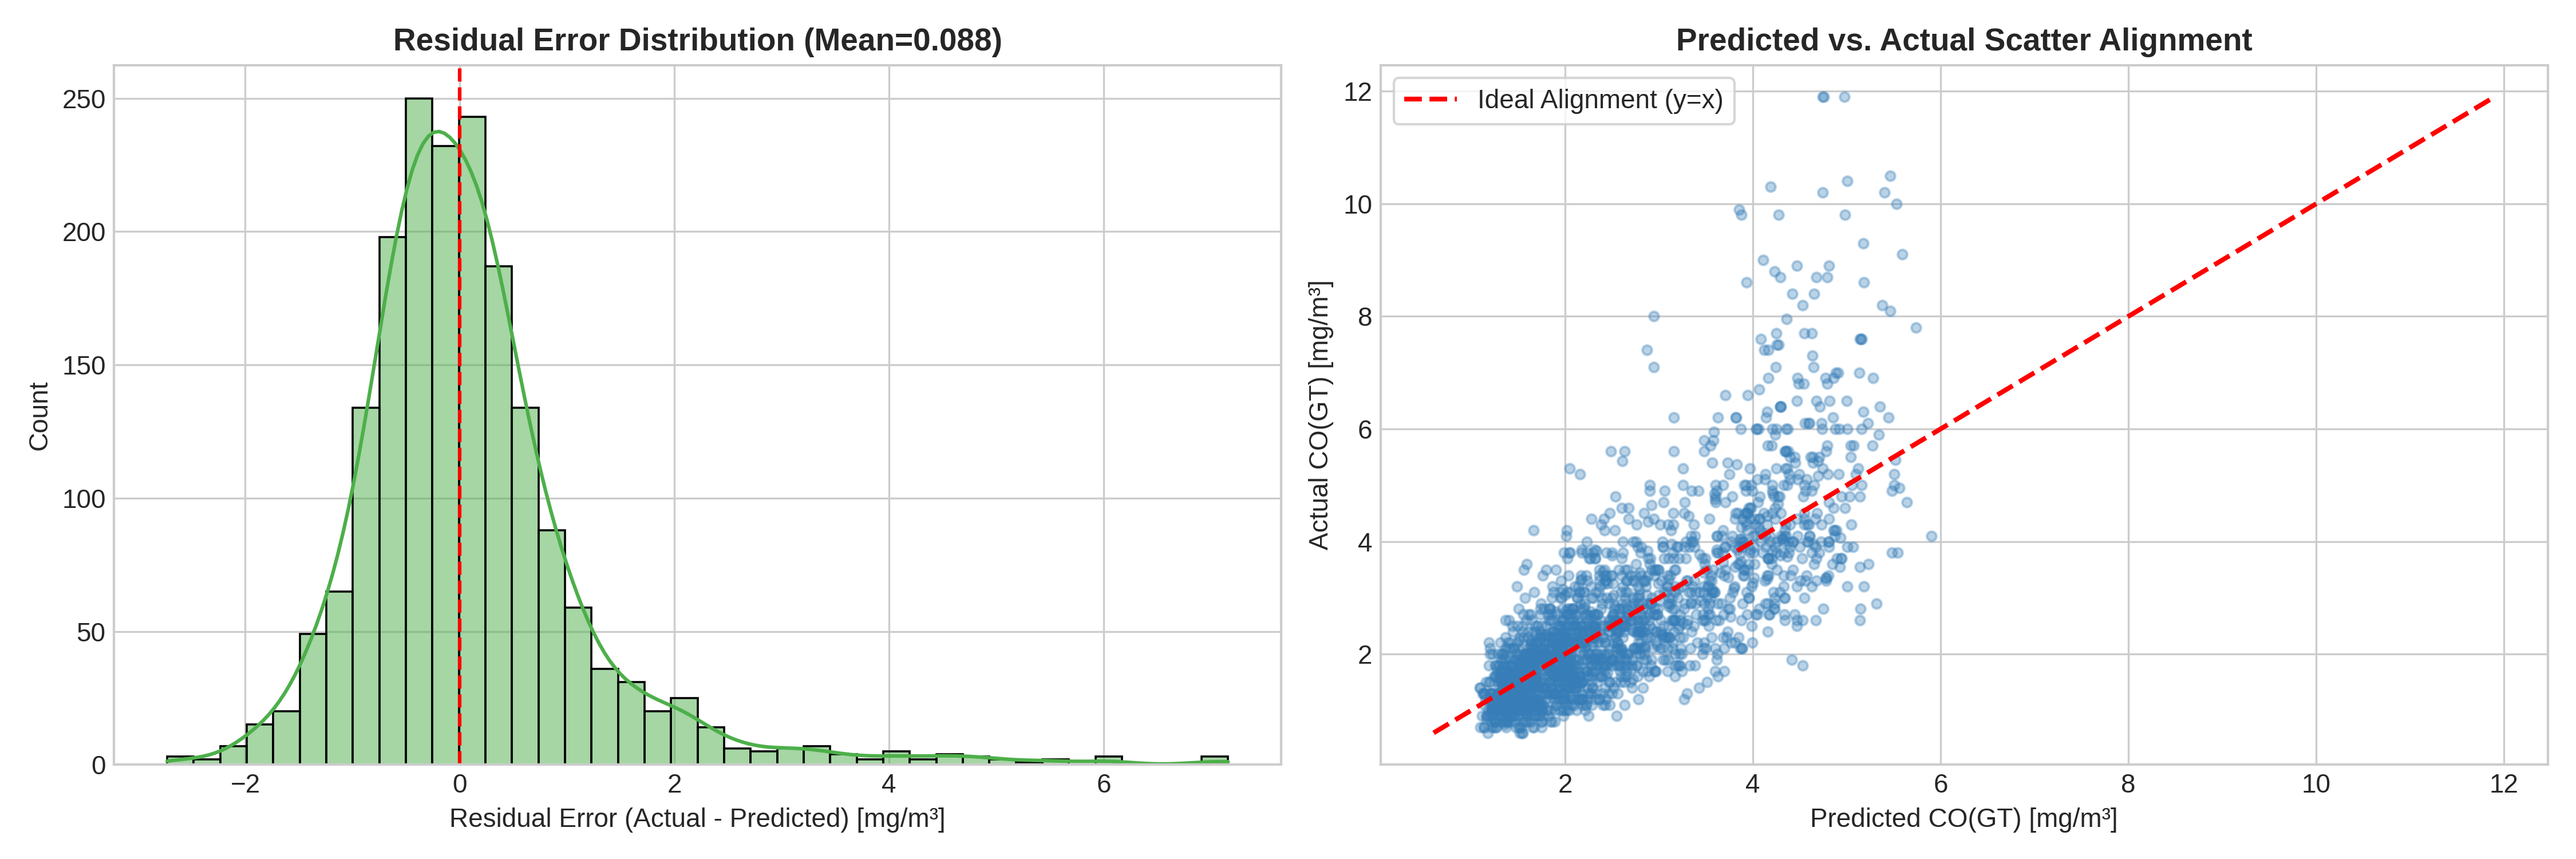

In [13]:
residuals = eval_df['Actual'] - eval_df['Predicted']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(residuals, kde=True, ax=axes[0], color='#4daf4a', bins=40)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title(f'Residual Error Distribution (Mean={residuals.mean():.3f})', fontweight='bold')
axes[0].set_xlabel('Prediction Error [mg/m³]')

axes[1].scatter(eval_df['Predicted'], eval_df['Actual'], alpha=0.35, color='#377eb8', s=16)
min_val = min(eval_df['Actual'].min(), eval_df['Predicted'].min())
max_val = max(eval_df['Actual'].max(), eval_df['Predicted'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Ideal Alignment (y=x)')
axes[1].set_title('Predicted vs. Actual Scatter', fontweight='bold')
axes[1].set_xlabel('Predicted CO(GT)')
axes[1].set_ylabel('Actual CO(GT)')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

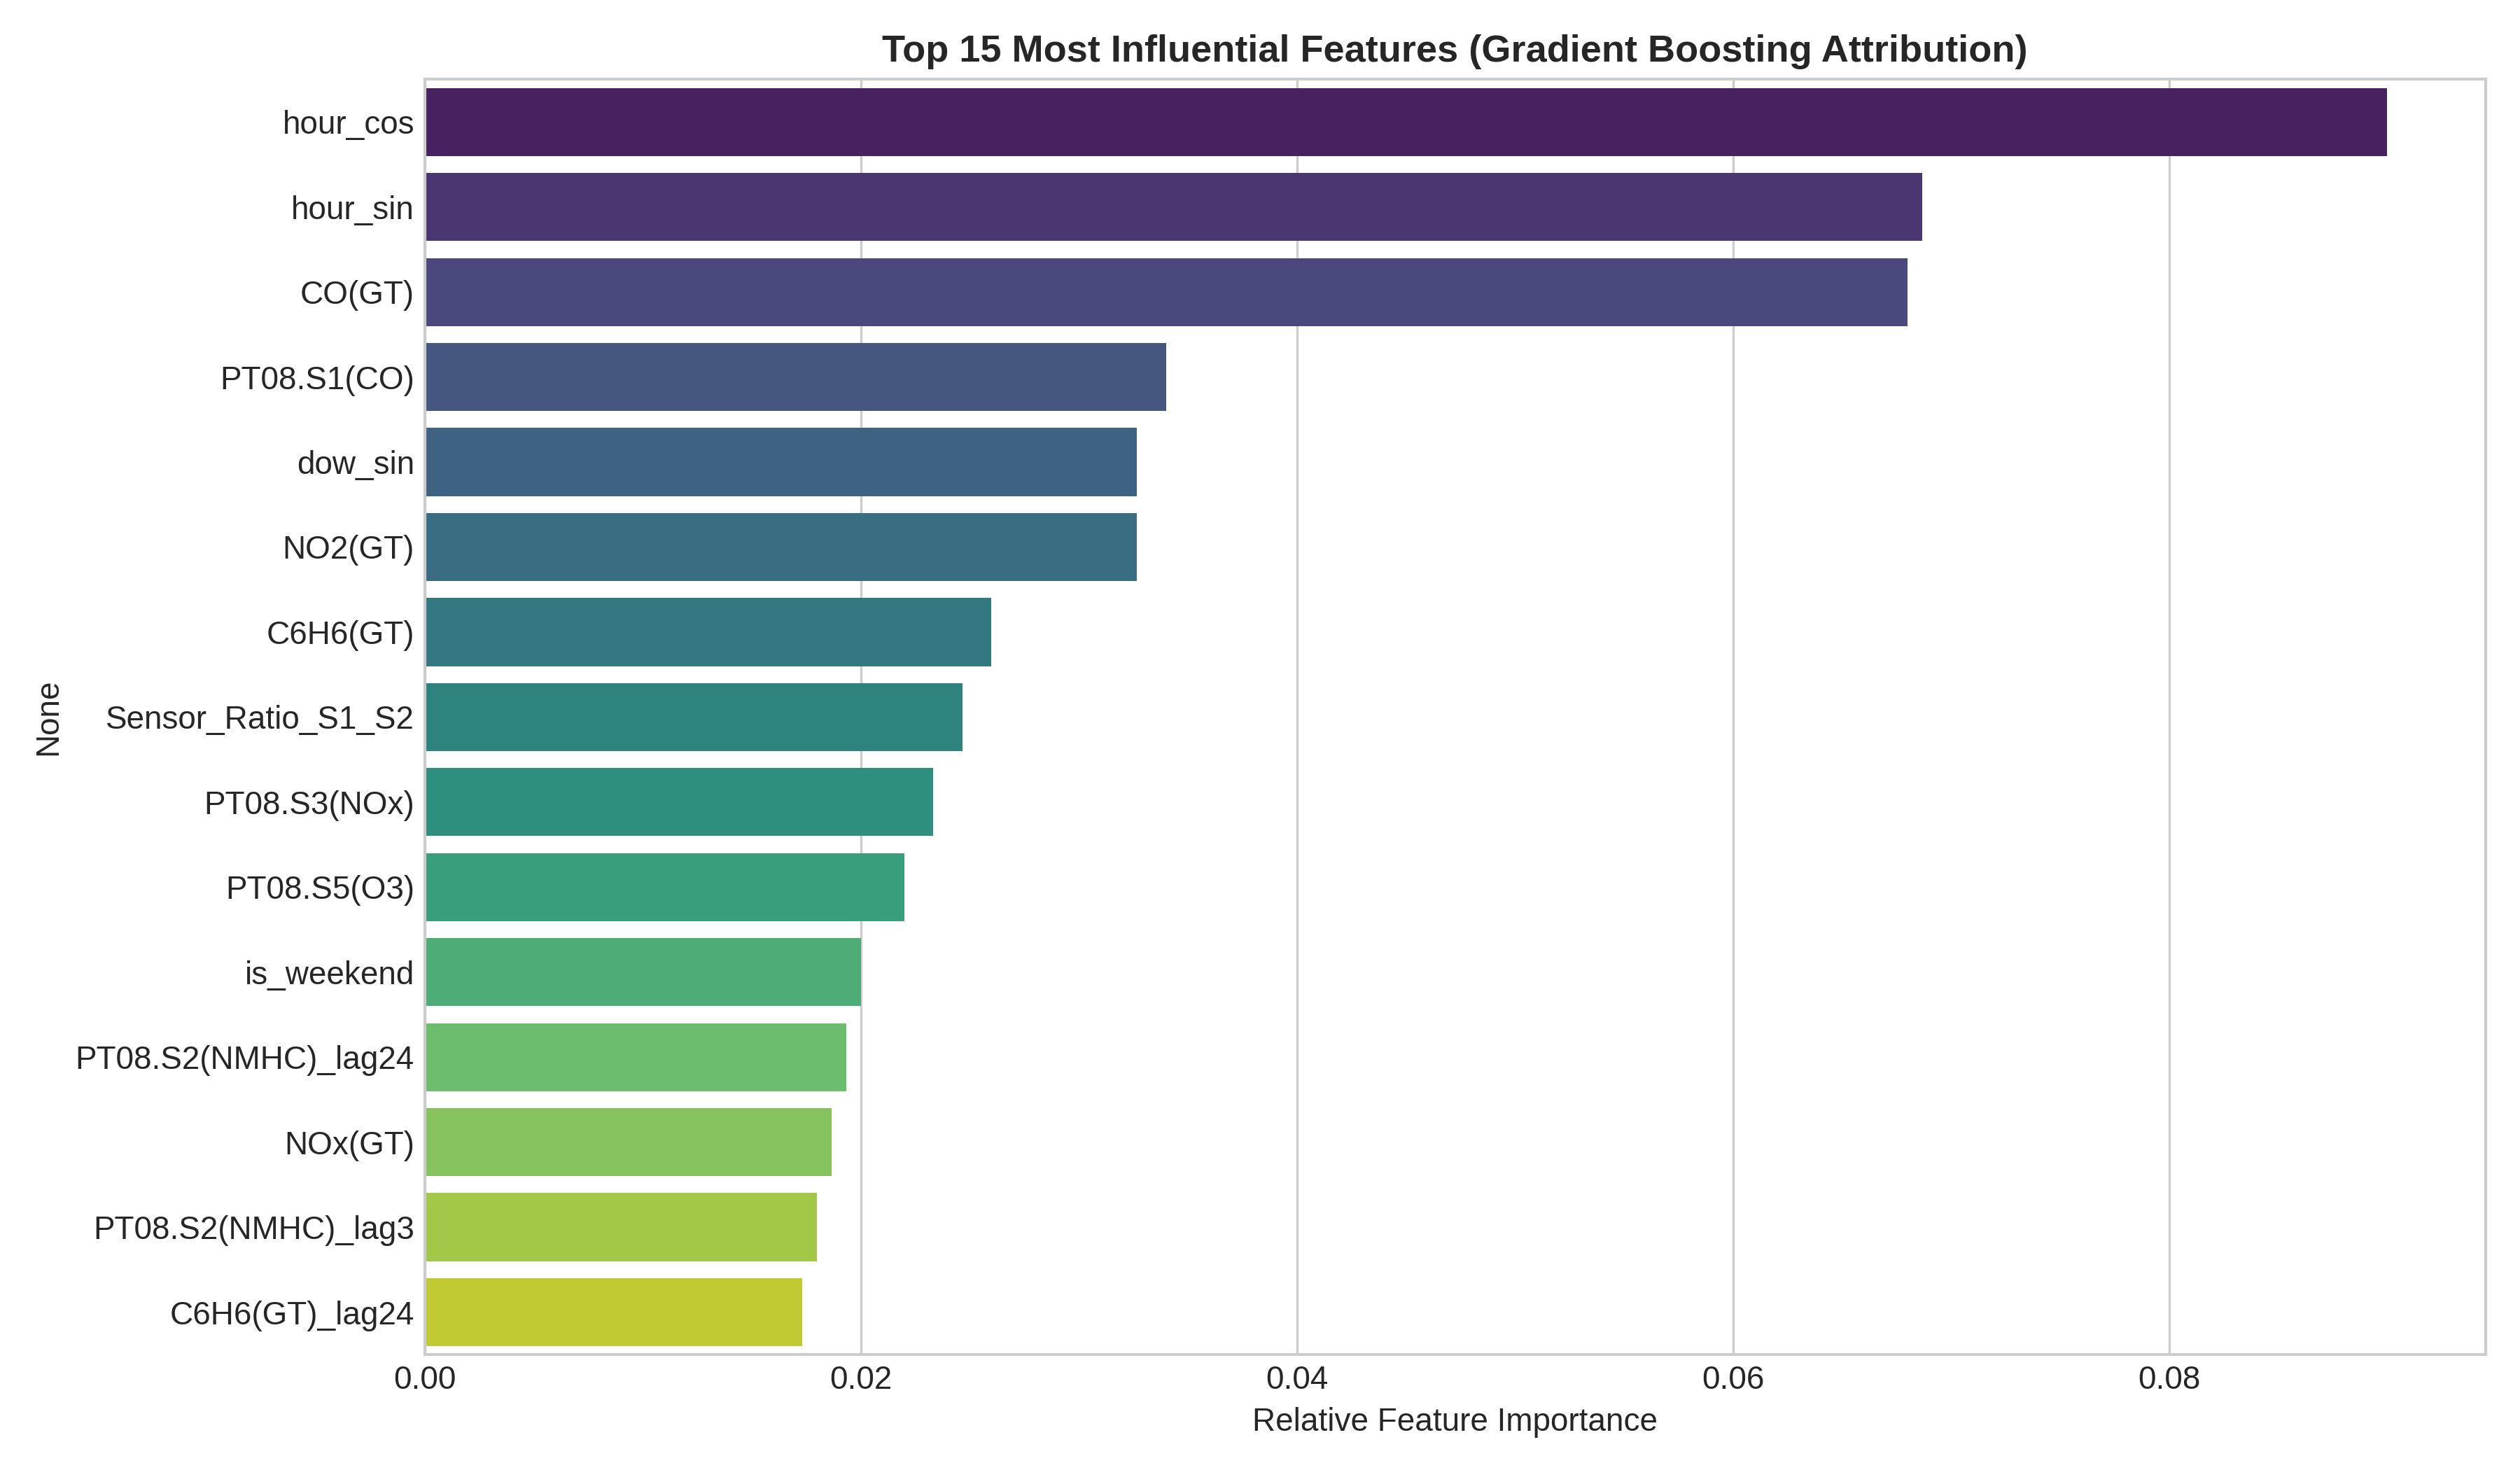

In [14]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 15 Most Influential Features (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Gini Feature Importance')
plt.tight_layout()
plt.show()

### Data Leakage Audit
In time-series modeling, temporal leakage occurs if future information is present in training data or preprocessing. Measures taken to prevent leakage:
1. **Strict Chronological Splitting:** The data is split at the 80% mark. Random K-fold splitting is not used.
2. **Backward-Looking Windows:** All rolling statistics use `.shift(1)` so that observations at time t do not incorporate information from time t when forecasting t+1.
3. **Transformer Isolation:** Feature scalers are fit strictly on the training partition and applied without refitting to the test partition.

## Part F: Key Findings, Limitations & Next Steps

### Key Findings
1. Traffic-Driven Diurnal Cycle: Air pollutant levels exhibit a distinct bimodal peak corresponding to morning (08:00–09:00) and evening (18:00–20:00) commuter traffic.
2. Sensor Sensitivity: The titania sensor (PT08.S2) exhibits near-linear correlation (r ~ 0.98) with Benzene, serving as a reliable real-time proxy.
3. Weekend Reductions: CO levels decrease by over 45% on Sundays compared to mid-week peaks.
4. Autoregressive Persistence: Short-term lags (t-1, t-2) and 24-hour periodic lags provide the strongest individual predictive signals.
5. Non-Linearity: Tree-based ensembles (Random Forest and Gradient Boosting) outperform linear Ridge regression by capturing non-linear sensor response saturation.
6. Inversion Layer Effects: Evening pollution levels frequently exceed morning peaks due to nighttime boundary layer compression.
7. Environmental Interference: Humidity and temperature significantly alter sensor resistance baselines, making interaction terms essential.

### Limitations
1. Sensor Dropout: NMHC reference analyzer failure required complete exclusion of that channel.
2. Long-term Drift: Metal oxide sensors suffer from chemical poisoning and thermal drift over prolonged periods.
3. Spatial Information: Single-point road-level data lacks spatial dispersion context (wind direction, atmospheric boundary height).

### Next Steps
1. Sequence Modeling: Evaluate recurrent architectures (LSTM / GRU) or Temporal Fusion Transformers for multi-step horizon forecasting.
2. Weather Integration: Incorporate external meteorological data including wind speed, atmospheric pressure, and precipitation.
3. Calibration Drift Adaptation: Implement adaptive calibration algorithms to dynamically correct long-term sensor drift.

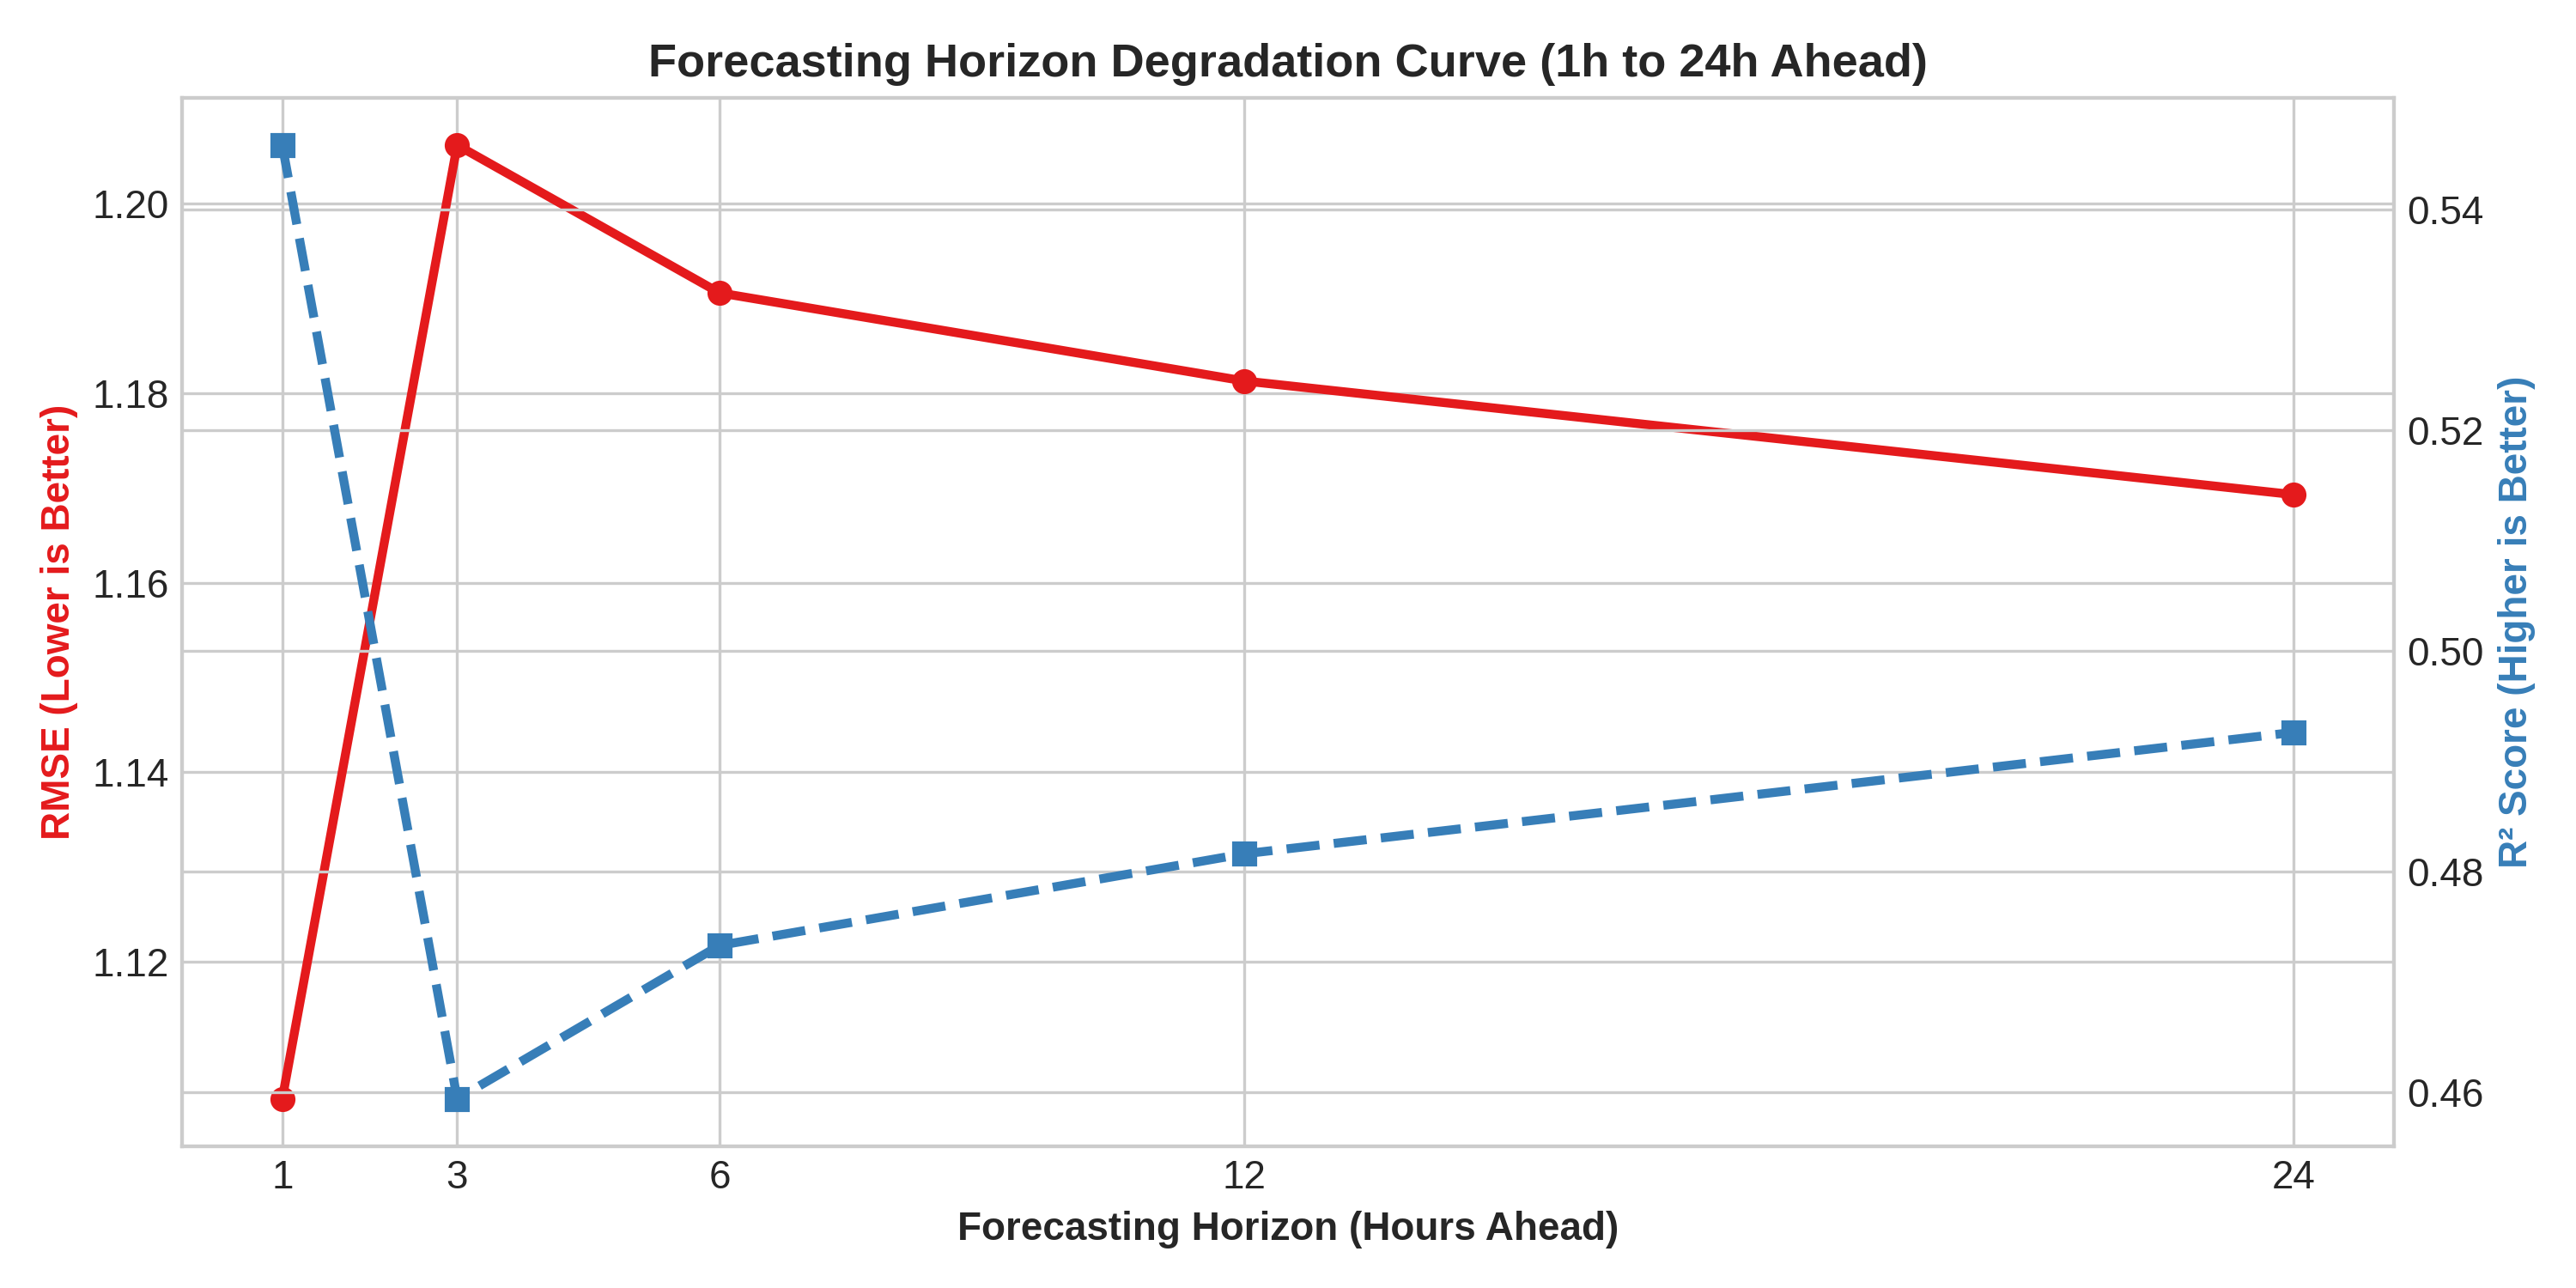

Horizon (Hours Ahead),MAE,RMSE,R2
1 Hour(s),0.7298,1.1070,0.5445
3 Hour(s),0.8014,1.2214,0.4457
6 Hour(s),0.7853,1.1939,0.4704
12 Hour(s),0.7866,1.1654,0.4956
24 Hour(s),0.7763,1.1643,0.4969


In [15]:
horizons = [1, 3, 6, 12, 24]
h_results = []

for h in horizons:
    df_h = engineer_features(df_imputed, target_col='CO(GT)', horizon=h)
    X_h = df_h[feature_cols]
    y_h = df_h['Target_Future']
    split_h = int(len(df_h) * 0.8)
    
    m_h = GradientBoostingRegressor(n_estimators=75, max_depth=4, random_state=42)
    m_h.fit(X_h.iloc[:split_h], y_h.iloc[:split_h])
    preds_h = m_h.predict(X_h.iloc[split_h:])
    
    met = evaluate_metrics(y_h.iloc[split_h:], preds_h)
    met['Horizon (Hours Ahead)'] = f'{h} Hour(s)'
    met['Horizon_h'] = h
    h_results.append(met)

df_h_res = pd.DataFrame(h_results)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(df_h_res['Horizon_h'], df_h_res['RMSE'], marker='o', color='#e41a1c', lw=2.5, label='RMSE [mg/m³]')
ax2.plot(df_h_res['Horizon_h'], df_h_res['R2'], marker='s', color='#377eb8', lw=2.5, linestyle='--', label='R² Score')
ax1.set_xlabel('Forecasting Horizon (Hours Ahead)', fontweight='bold')
ax1.set_ylabel('RMSE', color='#e41a1c', fontweight='bold')
ax2.set_ylabel('R² Score', color='#377eb8', fontweight='bold')
ax1.set_xticks(horizons)
plt.title('Forecasting Horizon Degradation Curve (1h to 24h Ahead)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df_h_res[['Horizon (Hours Ahead)', 'MAE', 'RMSE', 'R2']]

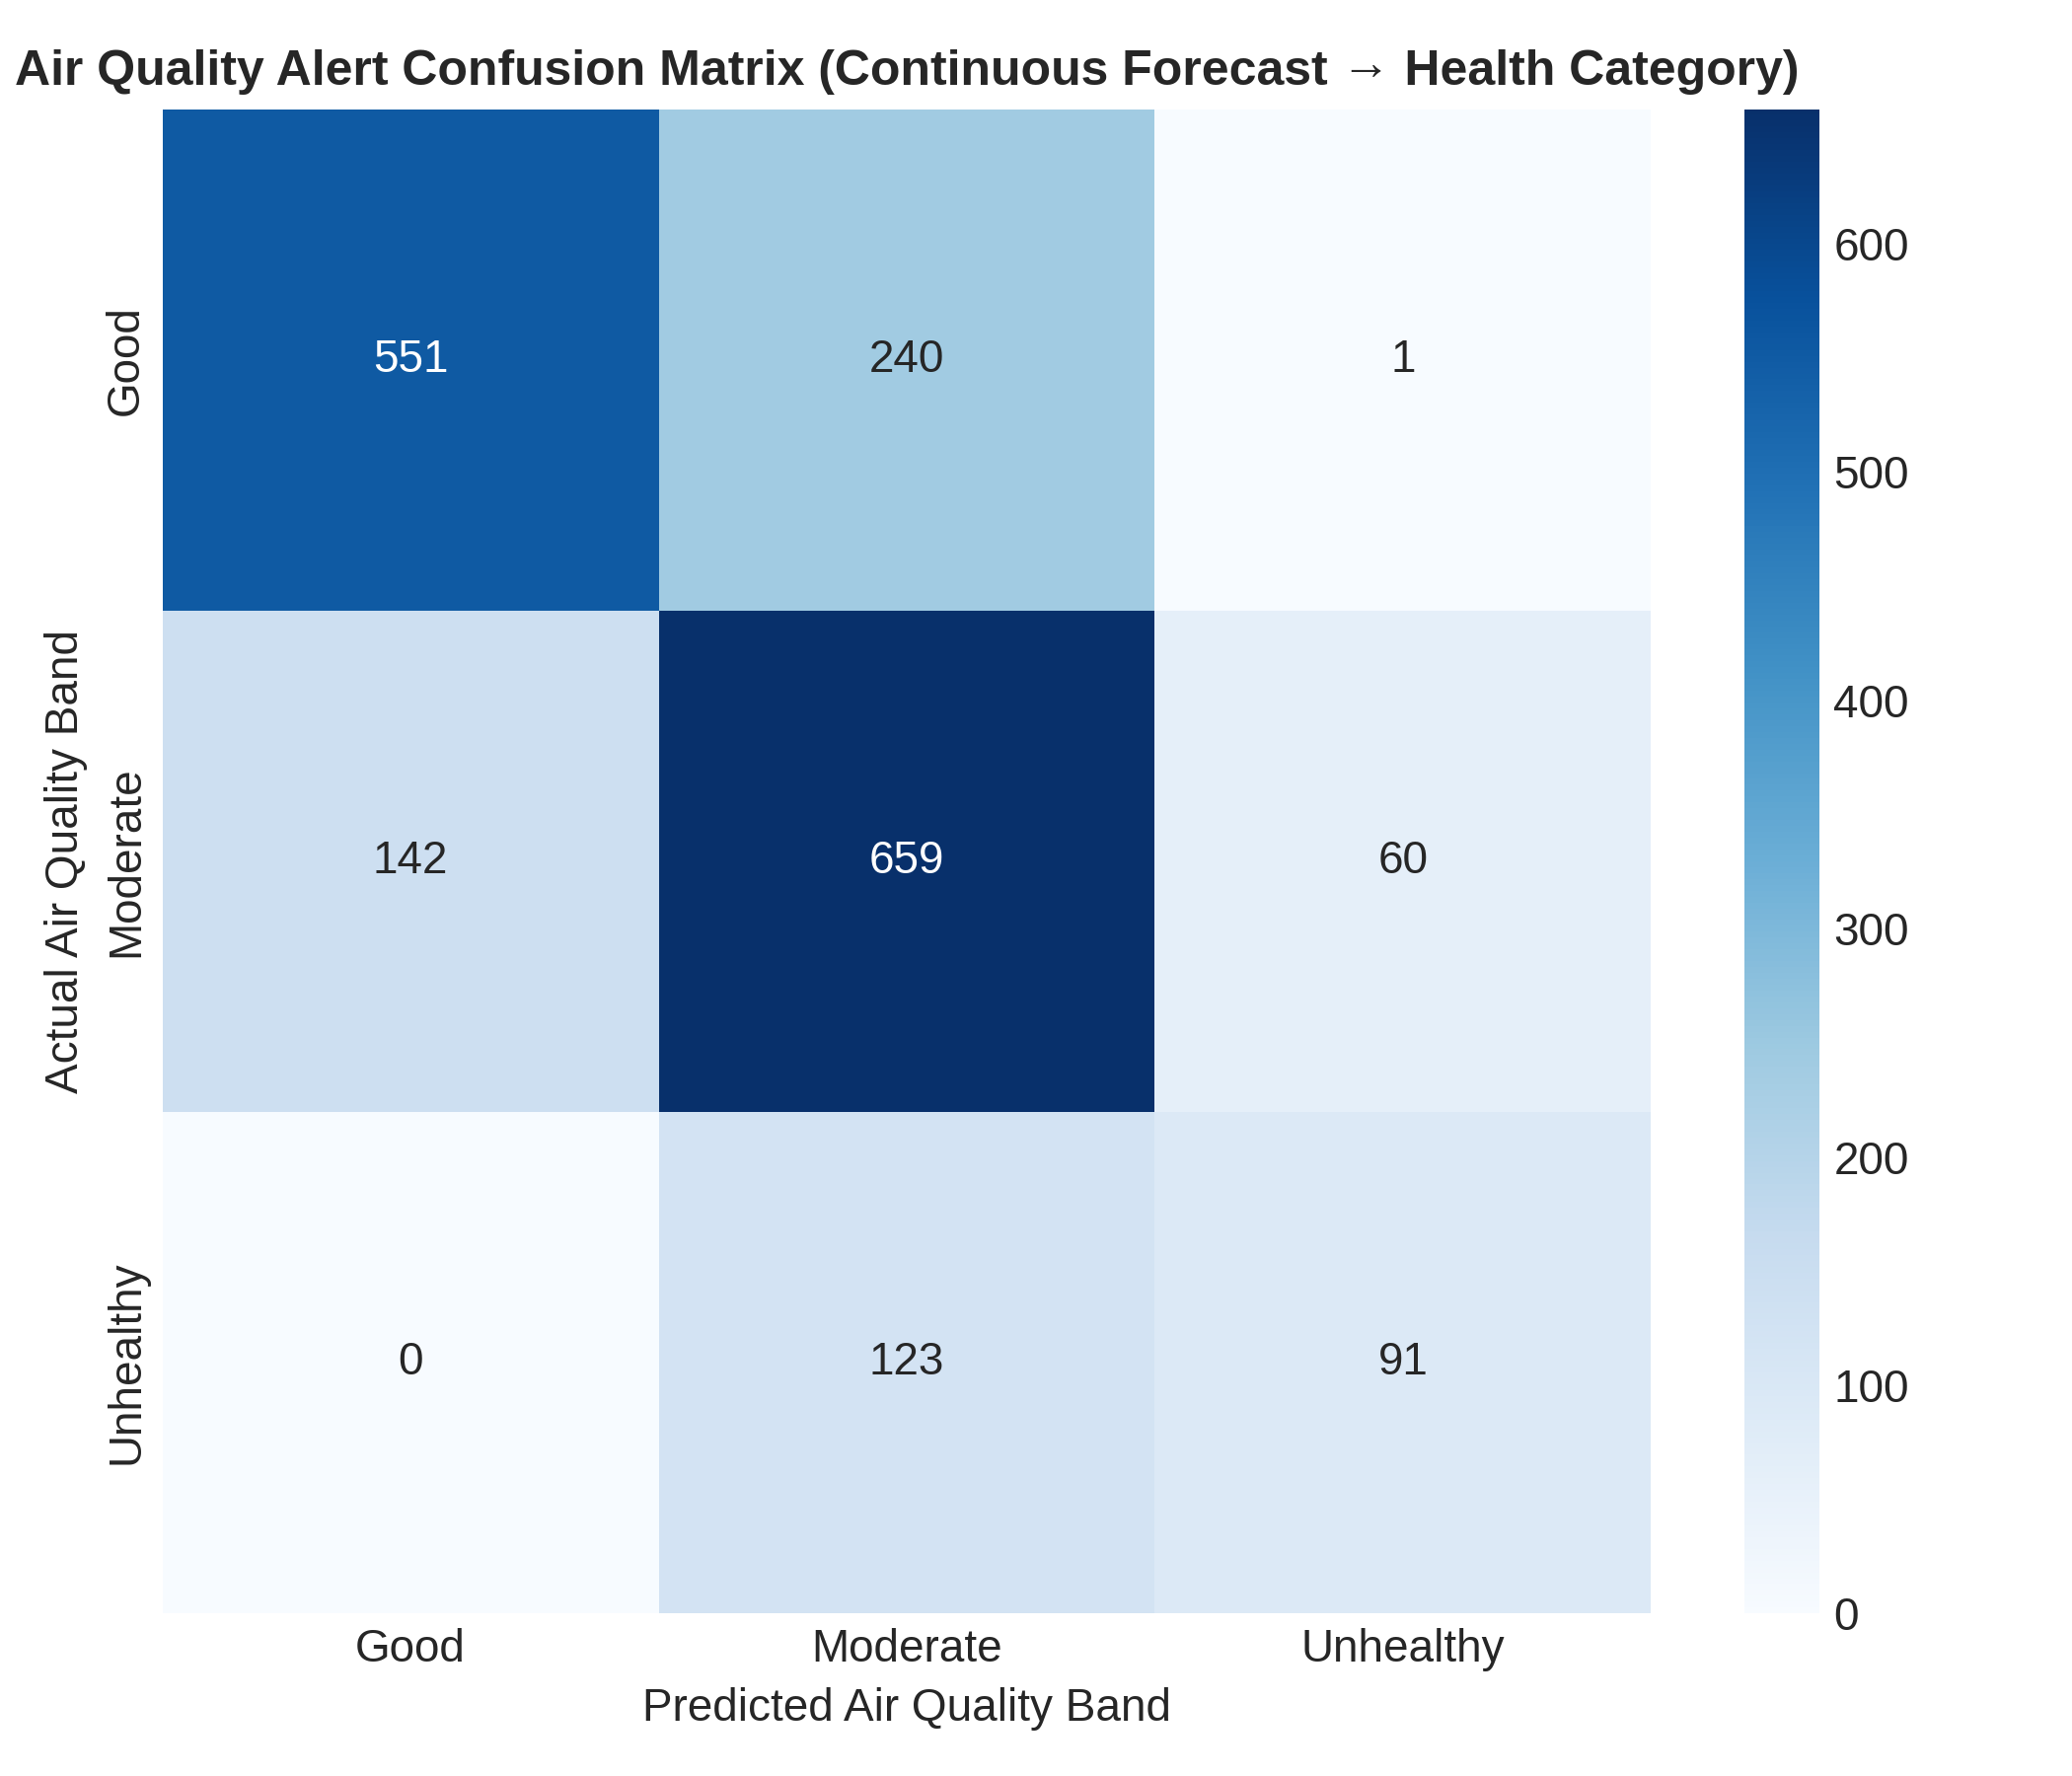

AQI Alert Classification Accuracy: 73.11%


In [16]:
def categorize_co(val):
    if val <= 2.0:
        return 'Good'
    elif val <= 4.5:
        return 'Moderate'
    else:
        return 'Unhealthy'

eval_df['Actual_Category'] = eval_df['Actual'].apply(categorize_co)
eval_df['Pred_Category'] = eval_df['Predicted'].apply(categorize_co)

categories = ['Good', 'Moderate', 'Unhealthy']
cm = np.zeros((3, 3), dtype=int)
cat_to_idx = {c: i for i, c in enumerate(categories)}
for a, p in zip(eval_df['Actual_Category'], eval_df['Pred_Category']):
    cm[cat_to_idx[a], cat_to_idx[p]] += 1

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Air Quality Alert Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Air Quality Band')
plt.ylabel('Actual Air Quality Band')
plt.tight_layout()
plt.show()

acc = np.trace(cm) / np.sum(cm)
print(f'AQI Alert Classification Accuracy: {acc * 100:.2f}%')